# Multistage & Mission Architecture

Demonstrates the multistage/mission architecture as it is built up commit by commit (see `mission_multistage_design.md`). Each section below corresponds to one landed commit. This is the last item on the original roadmap - see "Not built yet" at the bottom for what's deliberately still out of scope.

**Landed so far:**
1. `Stage` — wraps a single-stage `Rocket`
2. `Deployable` — a carried payload released mid-flight
3. `MultiStageRocket` — composes a stage + its deployables into one flight-ready `Rocket`
4. `MultiStageRocket.flight_rocket` for more than one active stage (a booster with an inert sustainer riding on top)
5. `Mission` — orchestrates one `Flight` per vehicle configuration: the single-stage degenerate case, a full two-stage mission (deterministic burnout+delay separation, state handoff, ignition timing), and a deployable ejecting at apogee
6. `MultiStageRocket.draw()` and `Mission.all_flights` — visualizing the stacked vehicle and comparing trajectories across bodies, both by reusing RocketPy's existing plotting (`Rocket.plots`, `CompareFlights`) rather than building anything new


In [1]:
from rocketpy import NoseCone, Rocket, SolidMotor
from rocketpy.rocket.multistage import Deployable, MultiStageRocket, Stage

## Building a base rocket

`Stage` and `MultiStageRocket` wrap ordinary `Rocket` objects — nothing new is needed to build one. This is the same Calisto rocket used throughout the RocketPy docs.

In [2]:
Pro75M1670 = SolidMotor(
    thrust_source="../../data/motors/cesaroni/Cesaroni_M1670.eng",
    dry_mass=1.815,
    dry_inertia=(0.125, 0.125, 0.002),
    nozzle_radius=33 / 1000,
    grain_number=5,
    grain_density=1815,
    grain_outer_radius=33 / 1000,
    grain_initial_inner_radius=15 / 1000,
    grain_initial_height=120 / 1000,
    grain_separation=5 / 1000,
    grains_center_of_mass_position=0.397,
    center_of_dry_mass_position=0.317,
    nozzle_position=0,
    burn_time=3.9,
    throat_radius=11 / 1000,
    coordinate_system_orientation="nozzle_to_combustion_chamber",
)

calisto = Rocket(
    radius=127 / 2000,
    mass=14.426,
    inertia=(6.321, 6.321, 0.034),
    power_off_drag="../../data/rockets/calisto/powerOffDragCurve.csv",
    power_on_drag="../../data/rockets/calisto/powerOnDragCurve.csv",
    center_of_mass_without_motor=0,
    coordinate_system_orientation="tail_to_nose",
)
calisto.add_motor(Pro75M1670, position=-1.255)

print(f"calisto.dry_mass = {calisto.dry_mass:.4f} kg")
print(f"calisto.motor.burn_out_time = {calisto.motor.burn_out_time} s")

calisto.dry_mass = 16.2410 kg
calisto.motor.burn_out_time = 3.9 s


## `Stage`: wrapping a rocket as one stage of a vehicle

For now `Stage` is a thin wrapper: `dry_mass` and `burn_out_time` just forward to the wrapped `Rocket`'s own already-computed attributes. It becomes meaningful once `MultiStageRocket` composes several stages together (a later commit).

In [3]:
booster = Stage(name="booster", rocket=calisto)

print(f"booster.dry_mass = {booster.dry_mass:.4f} kg")
print(f"booster.burn_out_time = {booster.burn_out_time} s")

assert booster.dry_mass == calisto.dry_mass
assert booster.burn_out_time == calisto.motor.burn_out_time

booster.dry_mass = 16.2410 kg
booster.burn_out_time = 3.9 s


## `Deployable`: a payload carried and ejected mid-flight

A `Deployable` contributes only mass and inertia while attached. Its free-flight aerodynamics come from either a fully built `free_rocket`, or surfaces added one at a time with `add_surface()` — the two are mutually exclusive, and `add_surface()` requires `radius` to be set.

In [4]:
payload = Deployable(
    name="payload",
    mass=4.5,
    inertia=(0.1, 0.1, 0.001),
    position=1.10,
    radius=0.05,
)

print(f"payload.mass = {payload.mass} kg")
print(f"payload.position = {payload.position} m")
print(f"payload.surfaces (before add_surface) = {payload.surfaces}")

payload.mass = 4.5 kg
payload.position = 1.1 m
payload.surfaces (before add_surface) = []


In [5]:
# add_surface requires radius to be set
no_radius_payload = Deployable(
    name="no_radius_payload", mass=1.0, inertia=(0, 0, 0), position=0.5
)
nose = NoseCone(length=0.2, kind="vonKarman", base_radius=0.05, rocket_radius=0.05)
try:
    no_radius_payload.add_surface(nose, position=0.1)
except ValueError as error:
    print(f"Raised as expected: {error}")

Raised as expected: add_surface requires radius to be set on the deployable.


In [6]:
# add_surface and free_rocket are mutually exclusive
payload.add_surface(nose, position=0.1)
print(f"payload.surfaces (after add_surface) = {payload.surfaces}")

payload.surfaces (after add_surface) = [(<rocketpy.rocket.aero_surface.nose_cone.NoseCone object at 0x109109a90>, 0.1)]


## `MultiStageRocket`: composing a stage + deployable into one flight-ready `Rocket`

`flight_rocket()` composes the wrapped stage's mass/inertia/CoM with every deployable still aboard (parallel axis theorem), attaches the stage's motor, and reuses its aerodynamic surfaces and drag curve. Only a single active stage is supported so far — multi-stage composition (booster + sustainer together) is a later commit.

In [7]:
vehicle = MultiStageRocket(stages=[booster])
deployable = vehicle.add_deployable(
    name="payload", mass=4.5, inertia=(0.1, 0.1, 0.001), position=1.10
)

flight_rocket = vehicle.flight_rocket(
    active_stages=(booster,), carried_deployables=(deployable,)
)

# Hand-computed weighted average, independent of flight_rocket's own
# code path — same check used in tests/unit/rocket/test_multistage.py
expected_mass = calisto.mass + 4.5
expected_center_of_mass = (
    calisto.mass * calisto.center_of_mass_without_motor + 4.5 * 1.10
) / expected_mass

print(f"flight_rocket.mass = {flight_rocket.mass:.4f} kg (expected {expected_mass:.4f})")
print(
    f"flight_rocket.center_of_mass_without_motor = {flight_rocket.center_of_mass_without_motor:.4f} m "
    f"(expected {expected_center_of_mass:.4f})"
)

assert abs(flight_rocket.mass - expected_mass) < 1e-9
assert abs(
    flight_rocket.center_of_mass_without_motor - expected_center_of_mass
) < 1e-9

flight_rocket.mass = 18.9260 kg (expected 18.9260)
flight_rocket.center_of_mass_without_motor = 0.2615 m (expected 0.2615)


## Multiple active stages: a booster carrying an inert sustainer

When more than one stage is still attached, `flight_rocket()` treats `active_stages[0]` as the currently firing stage (its motor becomes the composed `Rocket`'s own motor) and every other active stage as inert cargo riding along - contributing its *full* current mass (structure + motor + unburned propellant), since its own motor clock hasn't started yet.

Each stage's own `Rocket` coordinate system is assumed to already be expressed in a shared stack frame - positions are used as-is. Deriving stack positions automatically from `interstage_lengths` and each stage's physical extent isn't implemented yet.

In [8]:
from rocketpy.motors.point_mass_motor import PointMassMotor

booster_rocket = Rocket(
    radius=0.1,
    mass=10.0,
    inertia=(1.0, 1.0, 0.01),
    power_off_drag=0.5,
    power_on_drag=0.6,
    center_of_mass_without_motor=0.0,
)
booster_rocket.add_motor(
    PointMassMotor(
        thrust_source=100, dry_mass=1.0, propellant_initial_mass=2.0, burn_time=1.0
    ),
    position=0.0,
)
two_stage_booster = Stage(name="booster", rocket=booster_rocket)

sustainer_rocket = Rocket(
    radius=0.08,
    mass=5.0,
    inertia=(0.5, 0.5, 0.005),
    power_off_drag=0.3,
    power_on_drag=0.4,
    center_of_mass_without_motor=2.0,
)
sustainer_rocket.add_motor(
    PointMassMotor(
        thrust_source=50, dry_mass=0.5, propellant_initial_mass=1.0, burn_time=1.0
    ),
    position=2.0,
)
sustainer = Stage(name="sustainer", rocket=sustainer_rocket)

two_stage_vehicle = MultiStageRocket(stages=[two_stage_booster, sustainer])

In [9]:
stacked = two_stage_vehicle.flight_rocket(
    active_stages=(two_stage_booster, sustainer)
)
print(f"stacked.mass = {stacked.mass} kg  (booster structure + full inert sustainer)")
print(f"stacked.center_of_mass_without_motor = {stacked.center_of_mass_without_motor:.4f} m")
print(f"stacked.motor is booster_rocket.motor -> {stacked.motor is booster_rocket.motor}")

after_separation = two_stage_vehicle.flight_rocket(active_stages=(sustainer,))
print(f"\nafter_separation.mass = {after_separation.mass} kg  (sustainer structure only)")
print(f"after_separation.motor is sustainer_rocket.motor -> "
      f"{after_separation.motor is sustainer_rocket.motor}")

assert stacked.mass == 10.0 + (5.0 + 0.5 + 1.0)
assert after_separation.mass == 5.0

stacked.mass = 16.5 kg  (booster structure + full inert sustainer)
stacked.center_of_mass_without_motor = 0.7879 m
stacked.motor is booster_rocket.motor -> True

after_separation.mass = 5.0 kg  (sustainer structure only)
after_separation.motor is sustainer_rocket.motor -> True


## Visualizing the vehicle: `MultiStageRocket.draw()`

`draw()` composes every stage exactly as `flight_rocket()` would for a flight with the whole stack attached, then hands the result to `Rocket`'s own `plots.draw()` unchanged - no new drawing code. This also means a real two-diameter stack (a wide booster under a narrower sustainer) renders correctly out of the box: `Rocket`'s tube-drawing already handles a radius change between surfaces, it just draws a step rather than a tapered adapter.

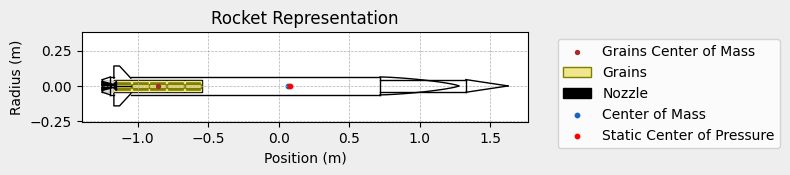

In [10]:
%matplotlib inline
from copy import deepcopy

# Draw a self-contained copy - deepcopy so this doesn't affect calisto's
# use in the later Mission sections below.
draw_booster_rocket = deepcopy(calisto)
draw_booster_rocket.add_nose(length=0.55829, kind="vonKarman", position=1.278)
draw_booster_rocket.add_trapezoidal_fins(
    n=3,
    root_chord=0.120,
    tip_chord=0.040,
    span=0.100,
    position=-1.04956,
)
draw_booster_rocket.add_tail(
    top_radius=0.0635, bottom_radius=0.0435, length=0.060, position=-1.194656
)
draw_booster = Stage(name="draw_booster", rocket=draw_booster_rocket)

# A second, narrower stage stacked on top - self-contained, its own
# rocket and nose cone, deliberately not reused anywhere else.
draw_sustainer_rocket = Rocket(
    radius=0.045,
    mass=3.0,
    inertia=(0.2, 0.2, 0.005),
    power_off_drag=0.5,
    power_on_drag=0.5,
    center_of_mass_without_motor=1.9,
)
# small interstage gap after the booster nose tip (x=1.278)
draw_sustainer_rocket.add_nose(length=0.3, kind="conical", position=1.628)
draw_sustainer = Stage(name="draw_sustainer", rocket=draw_sustainer_rocket)

draw_vehicle = MultiStageRocket(stages=[draw_booster, draw_sustainer])
draw_vehicle.draw()

## `Mission`: the degenerate single-flight case

`Mission` is the orchestrator that will eventually walk a vehicle's separation/ejection events and run one `Flight` per configuration with state handoff between them. Right now only the simplest case is implemented: a single-stage vehicle with no deployables degenerates to a thin wrapper around one `Flight` - confirming the invariant stated in `mission_multistage_design.md`. Anything else raises `NotImplementedError` for now.

A plain `Rocket` is sugar for a single-stage `MultiStageRocket` with nothing separable, so `Mission` accepts either directly.

In [11]:
from rocketpy import Environment
from rocketpy.simulation.mission import Mission

mission = Mission(
    vehicle=calisto,
    environment=Environment(),
    rail_length=5.2,
    inclination=85,
    heading=0,
)

print(f"bodies flown: {list(mission.flights.keys())}")
print(f"flights for 'stage_1': {mission.flights['stage_1']}")
print("\ntimeline:")
for time, event in mission.timeline:
    print(f"  t={time:8.3f}s  {event}")

bodies flown: ['stage_1']


flights for 'stage_1': [<Flight(rocket= <rocketpy.rocket.rocket.Rocket object at 0x11499d450>, environment= <rocketpy.environment.environment.Environment object at 0x114994980>, rail_length= 5.2, inclination= 85, heading = 0,name= stage_1)>]

timeline:
  t=   0.000s  ignition:stage_1
  t=   0.000s  liftoff
  t=   0.415s  rail_departure
  t=  48.436s  impact:stage_1


## `Mission`: a real two-stage flight

With two stages, `Mission` runs three `Flight`s: the full stack (booster firing), then the spent booster falling away on its own, and the sustainer continuing on its own. Separation and ignition timing are deterministic - computed ahead of time from `booster.burn_out_time + booster.separation` and `sustainer.ignition_delay` - there's no generic mid-flight event solver in RocketPy today, only `Flight`'s `max_time` and `terminate_on_apogee`.

The handoff between stack and children follows `mission_multistage_design.md`'s `_handoff_state`: the parent's ending position/velocity is transformed by the body-frame offset between the parent and child center-of-dry-mass, rotated into the inertial frame, plus (for the child) its momentum-conserving share of `separation_delta_v`. The sustainer's own motor is additionally re-anchored in time so it ignites at its actual mission time, not its own local t=0 (`_shift_motor_ignition`).

In [12]:
from rocketpy.motors.point_mass_motor import PointMassMotor

ts_booster_rocket = Rocket(
    radius=0.1,
    mass=10.0,
    inertia=(1.0, 1.0, 0.01),
    power_off_drag=0.5,
    power_on_drag=0.6,
    center_of_mass_without_motor=0.0,
)
ts_booster_rocket.add_motor(
    PointMassMotor(
        thrust_source=400, dry_mass=1.0, propellant_initial_mass=2.0, burn_time=1.0
    ),
    position=0.0,
)
# separation: burns out at t=1.0s, jettisoned 0.5s later
ts_booster = Stage(name="booster", rocket=ts_booster_rocket, separation=0.5)

ts_sustainer_rocket = Rocket(
    radius=0.08,
    mass=5.0,
    inertia=(0.5, 0.5, 0.005),
    power_off_drag=0.3,
    power_on_drag=0.4,
    center_of_mass_without_motor=2.0,
)
ts_sustainer_rocket.add_motor(
    PointMassMotor(
        thrust_source=200, dry_mass=0.5, propellant_initial_mass=1.0, burn_time=1.0
    ),
    position=2.0,
)
# ignites immediately on separation
ts_sustainer = Stage(name="sustainer", rocket=ts_sustainer_rocket, ignition_delay=0.0)

two_stage_vehicle = MultiStageRocket(stages=[ts_booster, ts_sustainer])

In [13]:
two_stage_mission = Mission(
    vehicle=two_stage_vehicle,
    environment=Environment(),
    rail_length=1.0,
    inclination=90,
    heading=0,
    max_time=30,
)

print(f"bodies flown: {list(two_stage_mission.flights.keys())}")
print(
    "'booster' flights (stack, then booster alone): "
    f"{len(two_stage_mission.flights['booster'])}"
)
print(
    "'sustainer' flights (stack, then sustainer alone): "
    f"{len(two_stage_mission.flights['sustainer'])}"
)
print("\ntimeline:")
for time, event in two_stage_mission.timeline:
    print(f"  t={time:8.3f}s  {event}")

Only one motor per rocket is currently supported. Overwriting previous motor.
bodies flown: ['booster', 'sustainer']
'booster' flights (stack, then booster alone): 2
'sustainer' flights (stack, then sustainer alone): 2

timeline:
  t=   0.000s  ignition:booster
  t=   0.000s  liftoff
  t=   0.426s  rail_departure
  t=   1.500s  separation:booster
  t=   1.500s  ignition:sustainer
  t=   3.774s  impact:booster
  t=   9.412s  impact:sustainer


/Users/dubeyishan371/Desktop/Rocketpy-main/RocketPy/rocketpy/simulation/flight.py:1555: UserWarning: A point-mass model was detected. Simulation mode should be '3 DOF'.
  warnings.warn(
/Users/dubeyishan371/Desktop/Rocketpy-main/RocketPy/rocketpy/motors/motor.py:1165: UserWarning: Reference pressure not set. Returning thrust instead.
  warnings.warn(


## `Mission`: a deployable ejecting at apogee

A single-stage vehicle with exactly one deployable whose `ejection` is the string `"apogee"` runs a different three-`Flight` sequence: the carrier stage flying with the deployable aboard (using the existing `terminate_on_apogee` flag on `Flight` - no new event machinery needed), then two children from the apogee state onward - the carrier stage continuing without the deployable's mass, and the deployable flying its own `free_rocket`.

Same `_handoff_state` transform as the two-stage case, and the same momentum-conserving delta_v split, just generalized: any two children of a split share `separation_delta_v` in inverse proportion to their post-split masses.

`ejection` other than `"apogee"`, and deployables defined via `add_surface()` instead of `free_rocket`, aren't supported yet.

In [14]:
carrier_rocket = Rocket(
    radius=0.1,
    mass=10.0,
    inertia=(1.0, 1.0, 0.01),
    power_off_drag=0.5,
    power_on_drag=0.6,
    center_of_mass_without_motor=0.0,
)
carrier_rocket.add_motor(
    PointMassMotor(
        thrust_source=400, dry_mass=1.0, propellant_initial_mass=2.0, burn_time=1.0
    ),
    position=0.0,
)
carrier = Stage(name="carrier", rocket=carrier_rocket)

payload_rocket = Rocket(
    radius=0.02,
    mass=1.0,
    inertia=(0.001, 0.001, 0.0001),
    power_off_drag=0.5,
    power_on_drag=0.5,
    center_of_mass_without_motor=0.0,
)

deployable_vehicle = MultiStageRocket(stages=[carrier])
deployable_vehicle.add_deployable(
    name="payload",
    mass=1.0,
    inertia=(0.001, 0.001, 0.0001),
    position=1.0,
    free_rocket=payload_rocket,
    ejection="apogee",
)

In [15]:
deployable_mission = Mission(
    vehicle=deployable_vehicle,
    environment=Environment(),
    rail_length=1.0,
    inclination=90,
    heading=0,
    max_time=20,
)

print(f"bodies flown: {list(deployable_mission.flights.keys())}")
print(
    "'carrier' flights (with payload, then alone): "
    f"{len(deployable_mission.flights['carrier'])}"
)
print(
    "'payload' flights (with carrier, then alone): "
    f"{len(deployable_mission.flights['payload'])}"
)
print("\ntimeline:")
for time, event in deployable_mission.timeline:
    print(f"  t={time:8.3f}s  {event}")

bodies flown: ['carrier', 'payload']
'carrier' flights (with payload, then alone): 2
'payload' flights (with carrier, then alone): 2

timeline:
  t=   0.000s  ignition:carrier
  t=   0.000s  liftoff
  t=   0.323s  rail_departure
  t=   3.114s  ejection:payload
  t=   5.661s  impact:carrier
  t=   5.667s  impact:payload


## Visualizing trajectories: `Mission.all_flights`

`all_flights` collects every `Flight` a `Mission` ran, in execution order, each appearing once even when several bodies shared it (the full stack's flight is one object, referenced by both `flights["booster"]` and `flights["sustainer"]`). It's built specifically to feed `CompareFlights` directly - no Mission-specific plotting code needed, the existing comparison plots already do everything asked for here.

/Users/dubeyishan371/Desktop/Rocketpy-main/RocketPy/rocketpy/plots/compare/compare_flights.py:1218: UserWarning: Attempting to set identical low and high ylims makes transformation singular; automatically expanding.
  ax1.set_ylim3d([min_xy, max_xy])
/Users/dubeyishan371/Desktop/Rocketpy-main/RocketPy/rocketpy/plots/compare/compare_flights.py:1219: UserWarning: Attempting to set identical low and high xlims makes transformation singular; automatically expanding.
  ax1.set_xlim3d([min_xy, max_xy])


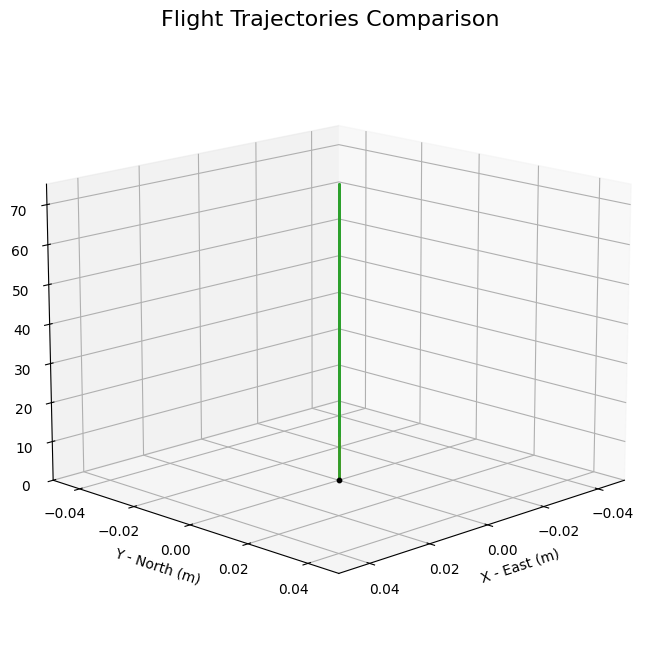

In [16]:
from rocketpy import CompareFlights

CompareFlights(two_stage_mission.all_flights).trajectories_3d()

/Users/dubeyishan371/Desktop/Rocketpy-main/RocketPy/rocketpy/plots/plot_helpers.py:65: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  fig.show()


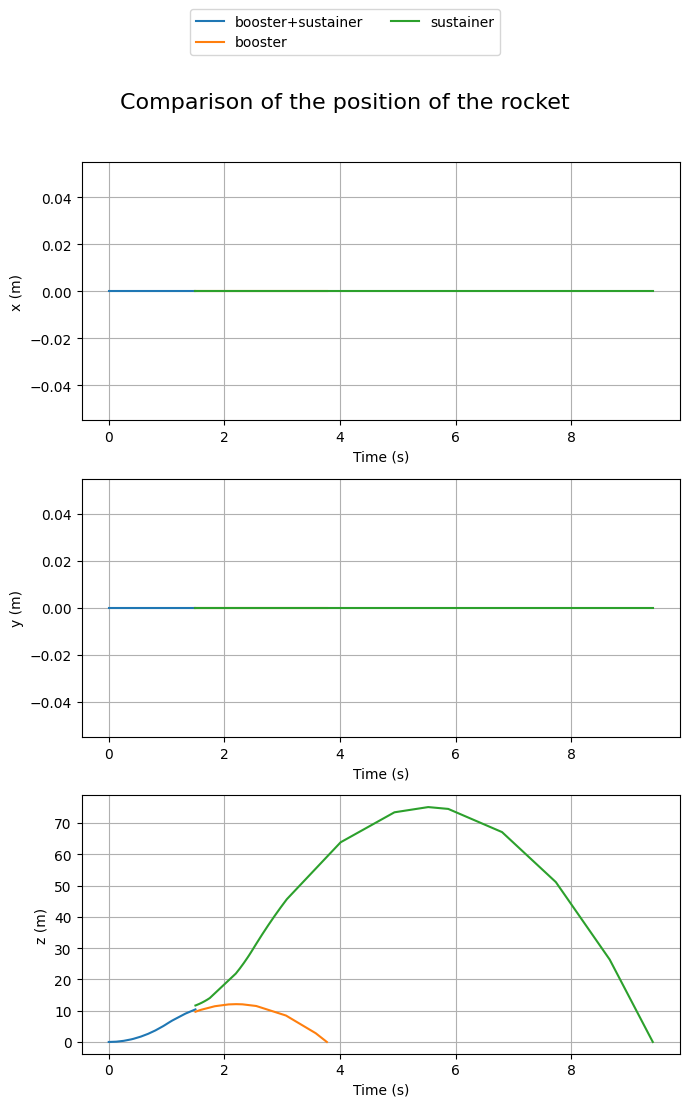

In [17]:
CompareFlights(two_stage_mission.all_flights).positions()

Same thing for the deployable mission - the carrier and the payload separate at apogee and fall along very similar paths, which is exactly what's expected given they split with zero `separation_delta_v`.

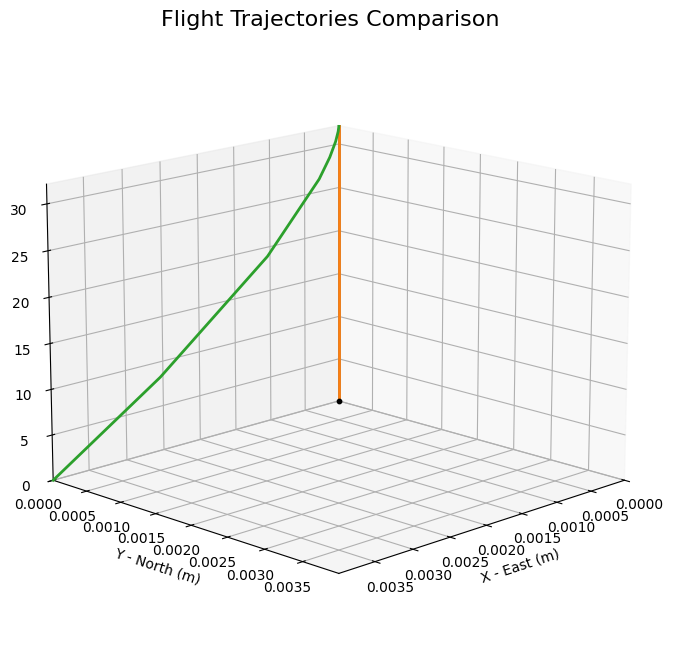

In [18]:
CompareFlights(deployable_mission.all_flights).trajectories_3d()

## Not built yet

Deliberately out of scope, not part of the original roadmap's 8 commits (see `mission_multistage_design.md`):

- More than two stages, or a deployable combined with a multi-stage vehicle
- Deriving stack positions from `interstage_lengths` and each stage's physical extent (stages are currently assumed to already share one coordinate frame)
- Event-triggered separation/ignition/ejection beyond deterministic delays and `"apogee"` (no generic mid-flight trigger/event solver exists in Flight today)
- Deployables built from `add_surface()` instead of `free_rocket`
- `StochasticMission`, `to_dict`/`from_dict`, `draw()`/`info()`
